Enter Excel/CSV file path: C:\Users\cugli\Desktop\冀东数据处理后结果\isotopeID.xlsx
Enter column name for [Age]: 207Pb/206Pb age
Enter column name for [Analytical Method]: Analytical instrument
Enter column name for [Rock Type]: Rock Type

✅ File loaded successfully! 8011 rows, 71 columns
📋 Columns: ['Sample ID', 'Reference No.', 'Sample No.', 'Rock name', 'Rock Type', 'Analytical object', 'Analytical instrument', 'Analytical institution', 'Analytical item', 'Analytical point', 'Age', '1s Age', 'U(ppm)', 'Th(ppm)', 'Pb(ppm)', 'Th/U', '207Pb/206Pb', '1s% 76', '207Pb/235U', '1s% 75', '206Pb/238U', '1s% 68', '238U/206Pb', '1s% 86', '208Pb/232Th', '1s% 82', '207Pb/206Pb age', '1s 76age', '207Pb/235U age', '1s 75age', '206Pb/238U age', '1s 68age', '208Pb/232Th age', '1s 82age', '206Pb/204Pb', '1s% 64', 'Discordance(%)', '206Pb/204Pb (Pb)', '207Pb/204Pb (Pb)', '208Pb/204Pb (Pb)', 'Lu(ppm)', 'Hf(ppm)', '176Yb/177Hf', '1s 176Yb/177Hf', '176Lu/177Hf', '1s 176Lu/177Hf', '176Hf/177Hf', '1s 176Hf/177Hf', '

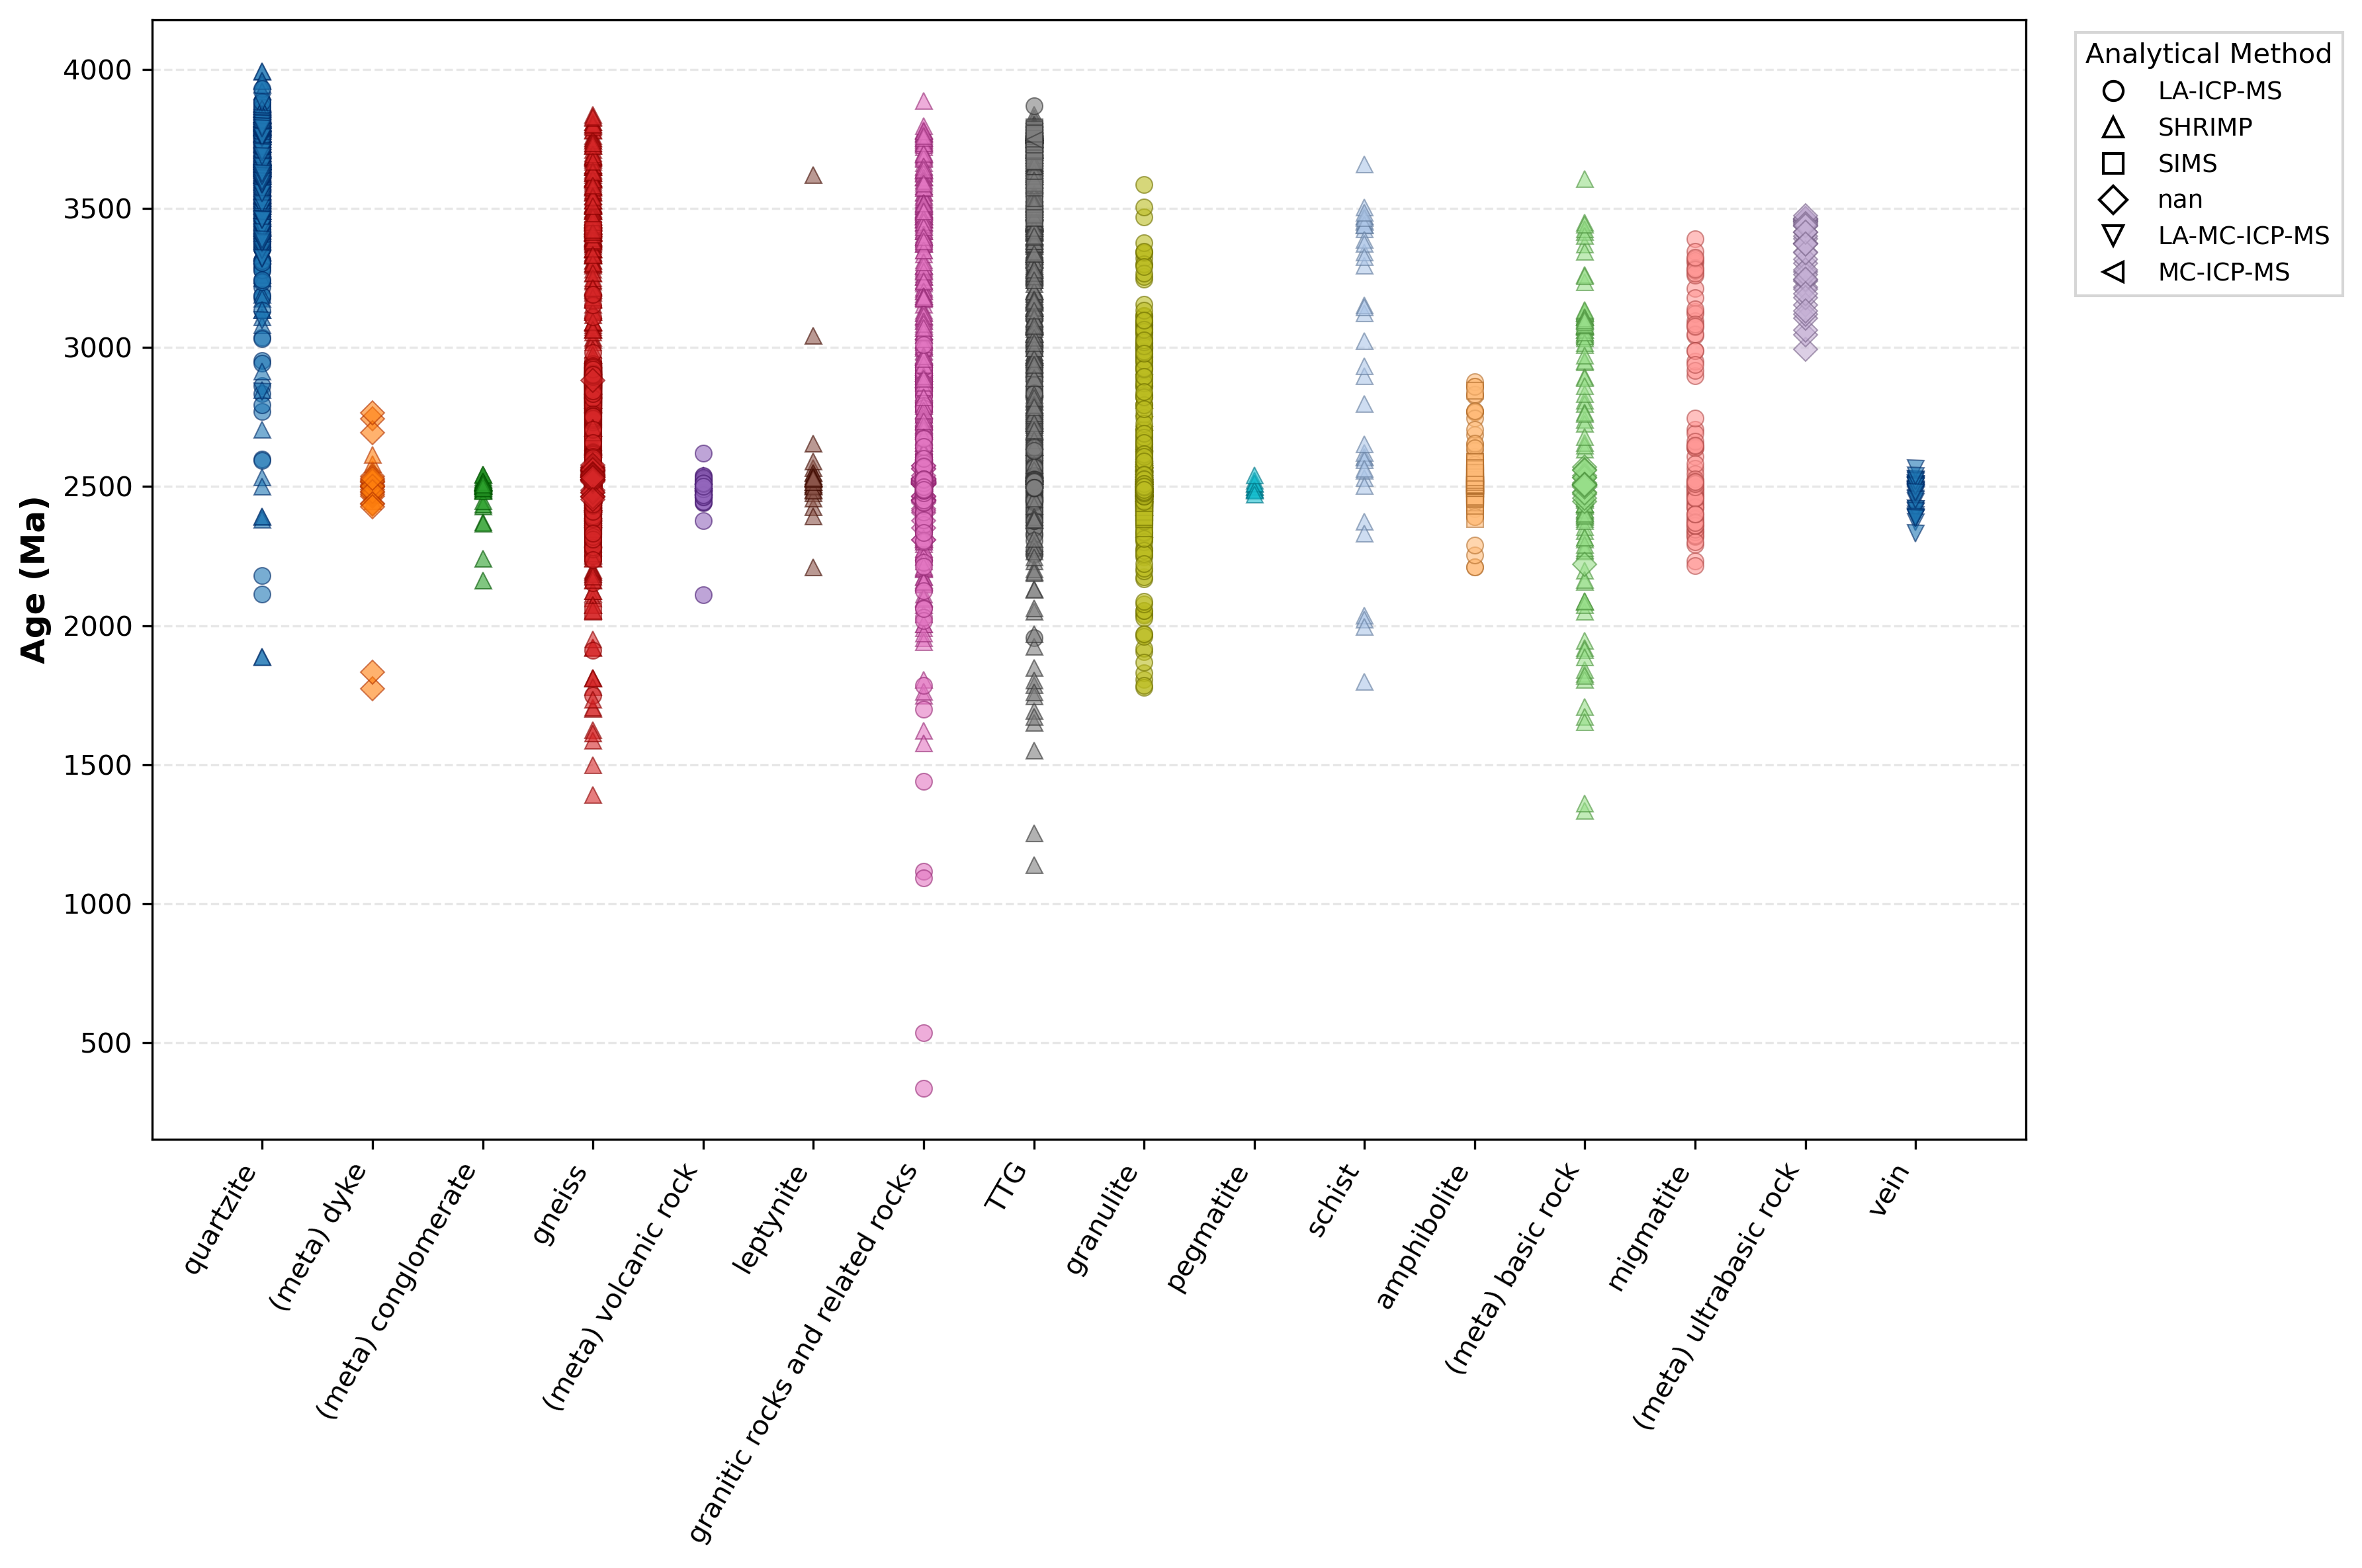


🎉 Plotting completed successfully!
📊 Output files:
  - Plots: Age_Distribution_Plot.svg / png
  - Statistics: Analytical_Method_Count.xlsx / Rock_Type_Count.xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib.colors as mc

# ====================== Suppress all warnings ======================
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.options.mode.chained_assignment = None
np.seterr(all='ignore')

# ====================== Plot settings ======================
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.size'] = 10

# Top journal standard color palette
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# Marker shapes for analytical methods
MARKERS = ['o', '^', 's', 'D', 'v', '<', '>', 'p', '*', 'X']

# Helper function: darken color
def darken_color(color, amount=0.3):
    c = mc.to_rgb(color)
    return tuple(max(0, x - amount) for x in c)

# ====================== Main interactive function ======================
def plot_age_distribution():
    # User inputs
    file_path = input("Enter Excel/CSV file path: ").strip().replace('"', '')
    age_col = input("Enter column name for [Age]: ").strip()
    method_col = input("Enter column name for [Analytical Method]: ").strip()
    rock_col = input("Enter column name for [Rock Type]: ").strip()

    # Read data
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
        print(f"\n✅ File loaded successfully! {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"📋 Columns: {list(df.columns)}\n")
    except Exception as e:
        print(f"❌ Failed to load file: {e}")
        return

    # Validate columns
    for col in [age_col, method_col, rock_col]:
        if col not in df.columns:
            print(f"❌ Column not found: {col}")
            return

    # Clean data: remove missing age values
    df_clean = df.dropna(subset=[age_col]).copy()
    df_clean = df_clean[pd.to_numeric(df_clean[age_col], errors='coerce').notna()]
    print(f"✅ Valid data points: {len(df_clean)}")

    if len(df_clean) == 0:
        print("❌ No valid age data available")
        return

    # Export analytical method counts
    method_counts = df_clean[method_col].value_counts(dropna=False).reset_index()
    method_counts.columns = ['Analytical Method', 'Count']
    method_counts.to_excel("Analytical_Method_Count.xlsx", index=False)
    print("✅ Saved: Analytical_Method_Count.xlsx")

    # Export rock type counts
    rock_counts = df_clean[rock_col].value_counts(dropna=False).reset_index()
    rock_counts.columns = ['Rock Type', 'Count']
    rock_counts.to_excel("Rock_Type_Count.xlsx", index=False)
    print("✅ Saved: Rock_Type_Count.xlsx")

    # Assign plot styles
    unique_methods = df_clean[method_col].unique()
    method_to_marker = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(unique_methods)}

    unique_rocks = df_clean[rock_col].unique()
    rock_to_color = {r: COLORS[i % len(COLORS)] for i, r in enumerate(unique_rocks)}

    x_pos_dict = {rock: i + 1 for i, rock in enumerate(unique_rocks)}
    df_clean['x_pos'] = df_clean[rock_col].map(x_pos_dict)

    # Create plot
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

    for idx, row in df_clean.iterrows():
        x = row['x_pos']
        y = row[age_col]
        marker = method_to_marker[row[method_col]]
        color_main = rock_to_color[row[rock_col]]
        edge_color = darken_color(color_main, 0.3)

        ax.plot(
            x, y,
            marker=marker,
            color=color_main,
            markeredgecolor=edge_color,
            markeredgewidth=0.5,
            markersize=6,
            alpha=0.6,
            linestyle=''
        )

    # Axis settings
    ax.set_ylabel('Age (Ma)', fontsize=12, fontweight='bold')
    ax.set_xlim(0, len(unique_rocks) + 1)
    ax.set_xticks(list(x_pos_dict.values()))
    ax.set_xticklabels(list(x_pos_dict.keys()), rotation=60, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=10)

    # Legend
    legend_handles = []
    for method, marker in method_to_marker.items():
        h = plt.Line2D([], [], marker=marker, color='black', linestyle='', 
                       markersize=7, markerfacecolor='white', markeredgewidth=1)
        legend_handles.append((h, method))

    handles, labels = zip(*legend_handles)
    ax.legend(
        handles, labels,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        title='Analytical Method',
        fontsize=9,
        frameon=True,
        fancybox=False
    )

    plt.tight_layout()
    plt.savefig("Age_Distribution_Plot.svg", format='svg', bbox_inches='tight')
    plt.savefig("Age_Distribution_Plot.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()

    print("\n🎉 Plotting completed successfully!")
    print("📊 Output files:")
    print("  - Plots: Age_Distribution_Plot.svg / png")
    print("  - Statistics: Analytical_Method_Count.xlsx / Rock_Type_Count.xlsx")

# ====================== Run ======================
plot_age_distribution()